In [507]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px 
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import Normalizer,StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error,mean_squared_error,mean_absolute_percentage_error
from sklearn.metrics import r2_score
import statsmodels.api as sm
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.tree import plot_tree

import warnings
warnings.filterwarnings("ignore")


In [508]:
df=pd.read_csv("C:\\Users\\Tracy\\Documents\\Data Set\\heart_disease_df_1.csv")
df.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0.0,125,212.0,0,1.0,168,0,NaN,2,2,3,0
1,53,1,0.0,140,203.0,1,0.0,155,1,NaN,0,0,3,0
2,70,1,0.0,145,174.0,0,1.0,125,1,NaN,0,0,3,0
3,61,1,0.0,148,203.0,0,1.0,161,0,NaN,2,1,3,0
4,62,0,0.0,138,294.0,1,1.0,106,0,NaN,1,3,2,0
5,58,0,0.0,100,248.0,0,0.0,122,0,NaN,1,0,2,1
6,58,1,0.0,114,318.0,0,2.0,140,0,NaN,0,3,1,0
7,55,1,0.0,160,289.0,0,0.0,145,1,NaN,1,1,3,0
8,46,1,0.0,120,249.0,0,0.0,144,0,NaN,2,0,3,0
9,54,1,0.0,122,286.0,0,0.0,116,1,NaN,1,2,2,0


In [509]:
df.tail(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
1066,52,1,0.0,125,212.0,0,1.0,168,0,NaN,2,2,3,0
1067,56,0,0.0,200,288.0,1,0.0,133,1,NaN,0,2,3,0
1068,62,1,1.0,128,208.0,1,0.0,140,0,NaN,2,0,2,1
1069,48,1,1.0,110,229.0,0,1.0,168,0,NaN,0,0,3,0
1070,51,0,2.0,140,308.0,0,0.0,142,0,NaN,2,1,2,1
1071,51,0,2.0,130,256.0,0,0.0,149,0,NaN,2,0,2,1
1072,54,0,NaN,160,201.0,0,1.0,163,0,NaN,2,1,2,1
1073,59,1,2.0,126,218.0,1,1.0,134,0,NaN,1,1,1,0
1074,58,0,1.0,136,319.0,1,0.0,152,0,NaN,2,2,2,0
1075,67,1,0.0,120,229.0,0,0.0,129,1,NaN,1,2,3,0


In [510]:
df.isna().sum()

age            0
sex            0
cp            53
trestbps       0
chol          55
fbs            0
restecg       48
thalach        0
exang          0
oldpeak     1076
slope          0
ca             0
thal           0
target         0
dtype: int64

In [511]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1076 entries, 0 to 1075
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1076 non-null   int64  
 1   sex       1076 non-null   int64  
 2   cp        1023 non-null   float64
 3   trestbps  1076 non-null   int64  
 4   chol      1021 non-null   float64
 5   fbs       1076 non-null   int64  
 6   restecg   1028 non-null   float64
 7   thalach   1076 non-null   int64  
 8   exang     1076 non-null   int64  
 9   oldpeak   0 non-null      float64
 10  slope     1076 non-null   int64  
 11  ca        1076 non-null   int64  
 12  thal      1076 non-null   int64  
 13  target    1076 non-null   int64  
dtypes: float64(4), int64(10)
memory usage: 117.8 KB


In [512]:
df.shape

(1076, 14)

In [513]:
Column_drop=df.drop(["oldpeak"],axis=1,inplace=True)


In [514]:
df.isna().sum()

age          0
sex          0
cp          53
trestbps     0
chol        55
fbs          0
restecg     48
thalach      0
exang        0
slope        0
ca           0
thal         0
target       0
dtype: int64

In [515]:
#Filling missing values
mean_value_chol=df["chol"].mean()
mean_value_chol
df["chol"].fillna(mean_value_chol,inplace=True)

mean_value_cp=df["cp"].mean()
mean_value_chol
df["cp"].fillna(mean_value_chol,inplace=True)


mean_value_cp=df["restecg"].mean()
mean_value_chol
df["restecg"].fillna(mean_value_chol,inplace=True)

df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [516]:
# from sklearn.impute import KNNImputer   
# imputer=KNNImputer(n_neighbors=2,weights="uniform")
# df_imputed=pd.DataFrame(imputer.fit_transform(df),columns=df.columns)
# print(df_imputed.isna().sum())

In [517]:
df.duplicated().sum()

np.int64(638)

In [518]:
duplicated_columns=df.drop_duplicates(inplace=True)

In [519]:
df.duplicated().sum()

np.int64(0)

# Data visualization

Correlation Heatmap

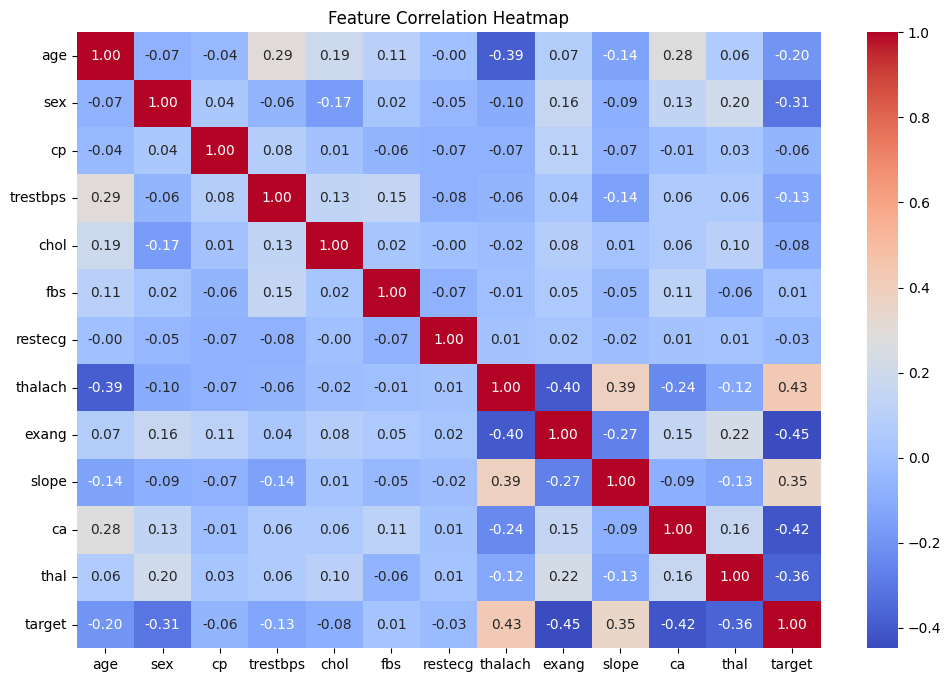

In [520]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()


Distribution Plots

Text(0.5, 1.0, 'Age Distribution')

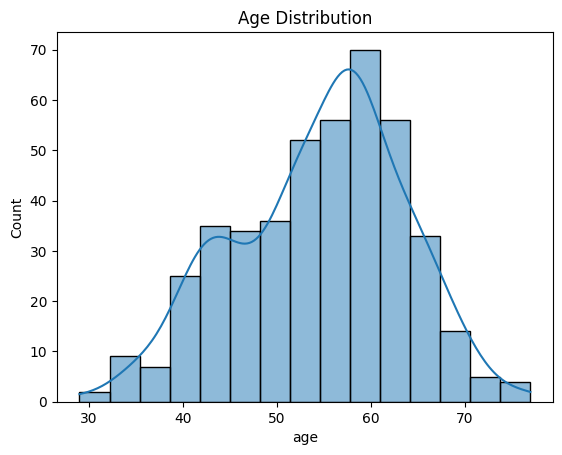

In [521]:
sns.histplot(df['age'], kde=True)
plt.title('Age Distribution')


Target Class Balance

Text(0.5, 1.0, 'Distribution of Heart Disease (Target)')

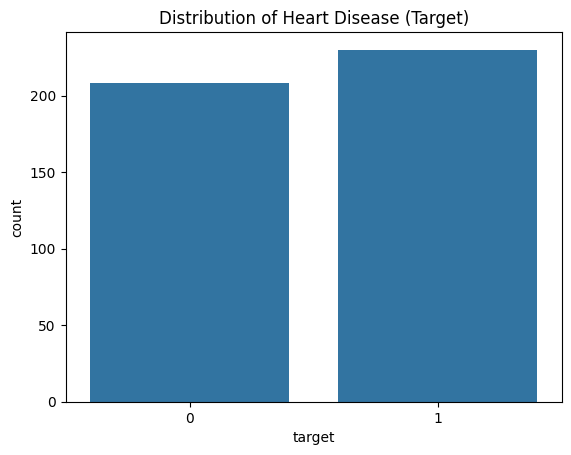

In [522]:
sns.countplot(x='target', data=df)
plt.title('Distribution of Heart Disease (Target)')


Text(0.5, 1.0, 'Confusion Matrix')

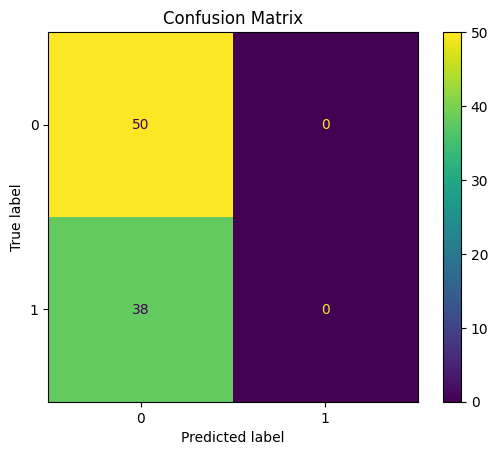

In [523]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
plt.title("Confusion Matrix")


In [524]:
#Feature Engingeerings
#Split Data into X and Y
X=df.drop('target',axis=1)
y=df["target"]

X_train, X_test, y_trian,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [525]:
norm=Normalizer()
X_train_norm=norm.fit_transform(X_train)
X_test_norm=norm.transform(X_test)

In [526]:
sc=StandardScaler()
X_train_sc=sc.fit_transform(X_train)
X_test_sc=sc.transform(X_test)

In [527]:
regression=LinearRegression()
regression.fit(X_train,y_trian)


LinearRegression()

In [528]:
reg_prediction=regression.predict(X_test)
score=r2_score(y_test,reg_prediction)
print(f" the R2_Score is {score}")
coef=regression.coef_
print(f"the coef is {coef}")
inter=regression.intercept_
print(f"the intercept is {inter}")
# What i noticed using the regression model is that, it perform so bad beccause it's a classification problem. so then i tried using claassifier to get a better prediction 


 the R2_Score is 0.4200564082970565
the coef is [ 2.18632440e-03 -2.09223731e-01  2.46773590e-05 -2.33375300e-03
 -6.68149997e-04  4.40066452e-02 -2.67259512e-04  4.65678893e-03
 -2.08634293e-01  1.29852648e-01 -1.32110586e-01 -1.34028441e-01]
the intercept is 0.6486588644959432


In [529]:
mse=mean_squared_error(y_test,reg_prediction)
mae=mean_absolute_error(y_test,reg_prediction)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

0.142289879162654
0.30654922975954774
0.37721330724492474


In [530]:
rf=RandomForestClassifier(n_jobs=-1,class_weight='balanced',n_estimators=300,
    max_depth=8,
    min_samples_split=5,
    min_samples_leaf=3,
    max_features='sqrt',
    random_state=42)
rf.fit(X_train,y_trian)

RandomForestClassifier(class_weight='balanced', max_depth=8, min_samples_leaf=3,
                       min_samples_split=5, n_estimators=300, n_jobs=-1,
                       random_state=42)

In [531]:
rf_prediction=rf.predict(X_test)
rf_prediction

accuracy = accuracy_score(y_test, rf_prediction)
conf_matrix = confusion_matrix(y_test, rf_prediction)
class_report = classification_report(y_test, rf_prediction)


print(f'Accuracy: {accuracy:.4f}')
print('Confusion Matrix:')
print(conf_matrix)
print('Classification Report:')
print(class_report)

Accuracy: 0.8523
Confusion Matrix:
[[40 10]
 [ 3 35]]
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.80      0.86        50
           1       0.78      0.92      0.84        38

    accuracy                           0.85        88
   macro avg       0.85      0.86      0.85        88
weighted avg       0.86      0.85      0.85        88



In [532]:
logistic_model= LogisticRegression()
logistic_model.fit(X_train_sc,y_trian)

LogisticRegression()

In [533]:
prediction=logistic_model.predict(X_test_sc)
prediction

array([0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1,
       1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1,
       0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0])

In [534]:
accuracy=accuracy_score(y_test,prediction)
print(f"the accuracy is {accuracy}")
conf_matric=confusion_matrix(y_test,prediction)
print(f"the conf_matric is {conf_matric}")
class_report=classification_report(y_test,prediction)
print(f"the class_report{class_report}")

the accuracy is 0.8522727272727273
the conf_matric is [[40 10]
 [ 3 35]]
the class_report              precision    recall  f1-score   support

           0       0.93      0.80      0.86        50
           1       0.78      0.92      0.84        38

    accuracy                           0.85        88
   macro avg       0.85      0.86      0.85        88
weighted avg       0.86      0.85      0.85        88



In [535]:
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_trian)

DecisionTreeClassifier()

In [536]:

dt_pred = dt_model.predict(X_test)
print("\nDecision Tree")
print("Accuracy:", accuracy_score(y_test, dt_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, dt_pred))
print("Classification Report:\n", classification_report(y_test, dt_pred))



Decision Tree
Accuracy: 0.8863636363636364
Confusion Matrix:
 [[44  6]
 [ 4 34]]
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.88      0.90        50
           1       0.85      0.89      0.87        38

    accuracy                           0.89        88
   macro avg       0.88      0.89      0.88        88
weighted avg       0.89      0.89      0.89        88



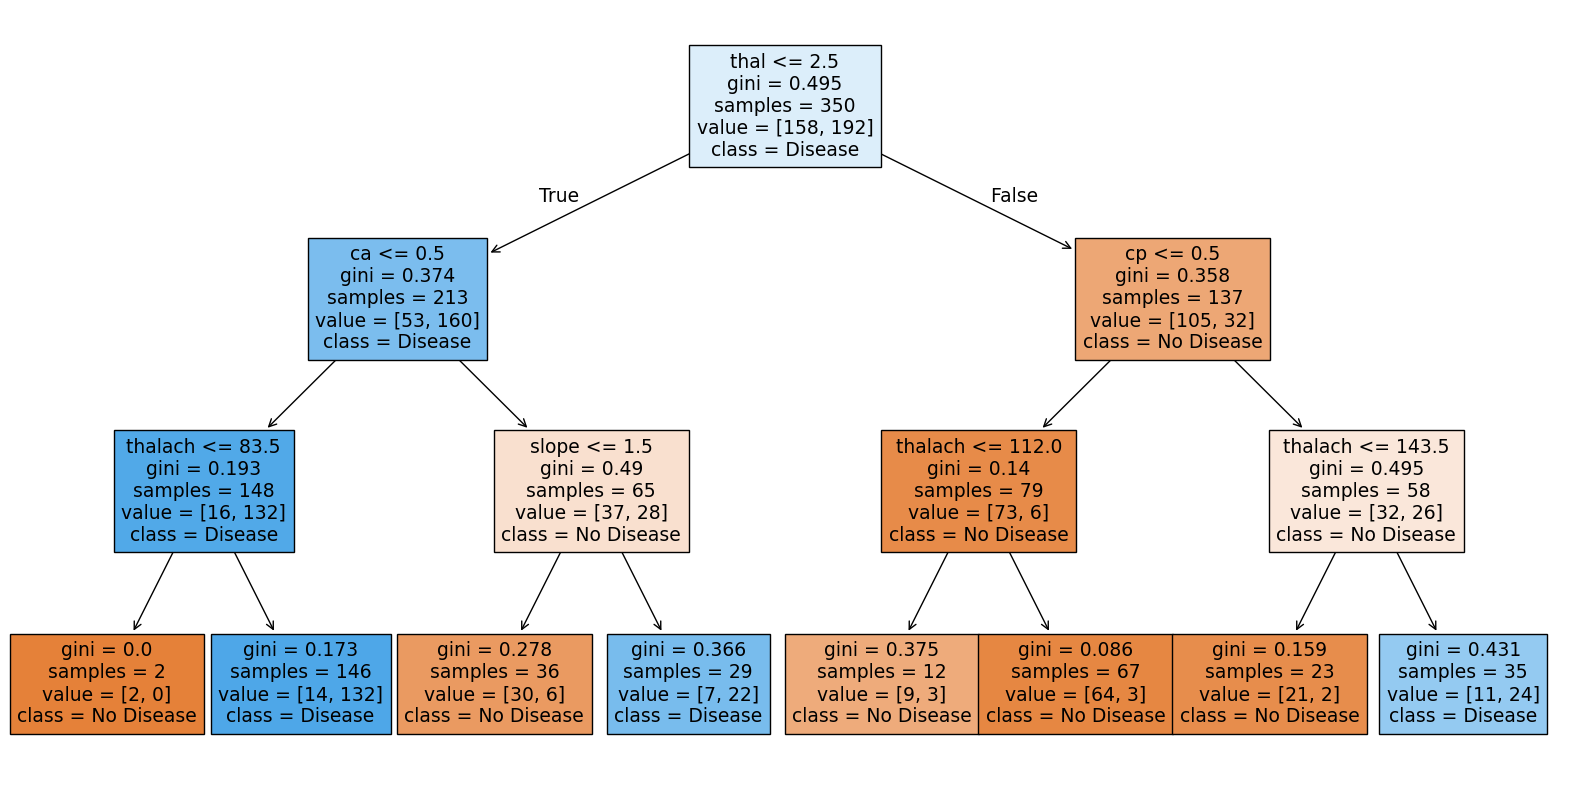

In [537]:


dt_model = DecisionTreeClassifier(max_depth=3, min_samples_split=5, min_samples_leaf=2)
dt_model.fit(X_train, y_trian)

# Now visualize
plt.figure(figsize=(20,10))
plot_tree(dt_model, 
          filled=True, 
          feature_names=X.columns, 
          class_names=["No Disease", "Disease"]);


In [538]:
svm_model = SVC()
svm_model.fit(X_train, y_trian)

SVC()

In [539]:

svm_pred = svm_model.predict(X_test)
print("\nSupport Vector Machine")
print("Accuracy:", accuracy_score(y_test, svm_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, svm_pred))
print("Classification Report:\n", classification_report(y_test, svm_pred))


Support Vector Machine
Accuracy: 0.6022727272727273
Confusion Matrix:
 [[20 30]
 [ 5 33]]
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.40      0.53        50
           1       0.52      0.87      0.65        38

    accuracy                           0.60        88
   macro avg       0.66      0.63      0.59        88
weighted avg       0.68      0.60      0.59        88



In [540]:
knn_model = KNeighborsClassifier()
knn_model.fit(X_train, y_trian)

KNeighborsClassifier()

In [541]:

knn_pred = knn_model.predict(X_test)
print("\nK-Nearest Neighbors")
print("Accuracy:", accuracy_score(y_test, knn_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, knn_pred))
print("Classification Report:\n", classification_report(y_test, knn_pred))



K-Nearest Neighbors
Accuracy: 0.6022727272727273
Confusion Matrix:
 [[20 30]
 [ 5 33]]
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.40      0.53        50
           1       0.52      0.87      0.65        38

    accuracy                           0.60        88
   macro avg       0.66      0.63      0.59        88
weighted avg       0.68      0.60      0.59        88



In [542]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_trian)

GaussianNB()

In [543]:

nb_pred = nb_model.predict(X_test)
print("\nNaive Bayes")
print("Accuracy:", accuracy_score(y_test, nb_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, nb_pred))
print("Classification Report:\n", classification_report(y_test, nb_pred))



Naive Bayes
Accuracy: 0.8295454545454546
Confusion Matrix:
 [[41  9]
 [ 6 32]]
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.82      0.85        50
           1       0.78      0.84      0.81        38

    accuracy                           0.83        88
   macro avg       0.83      0.83      0.83        88
weighted avg       0.83      0.83      0.83        88



In [544]:
gb_model = GradientBoostingClassifier()
gb_model.fit(X_train, y_trian)

GradientBoostingClassifier()

In [545]:

gb_pred = gb_model.predict(X_test)
print("\nGradient Boosting")
print("Accuracy:", accuracy_score(y_test, gb_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, gb_pred))
print("Classification Report:\n", classification_report(y_test, gb_pred))


Gradient Boosting
Accuracy: 0.8636363636363636
Confusion Matrix:
 [[40 10]
 [ 2 36]]
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.80      0.87        50
           1       0.78      0.95      0.86        38

    accuracy                           0.86        88
   macro avg       0.87      0.87      0.86        88
weighted avg       0.88      0.86      0.86        88



In [546]:
mlp_model = MLPClassifier(max_iter=1000)
mlp_model.fit(X_train, y_trian)

MLPClassifier(max_iter=1000)

In [547]:

mlp_pred = mlp_model.predict(X_test)
print("\nNeural Network")
print("Accuracy:", accuracy_score(y_test, mlp_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, mlp_pred))
print("Classification Report:\n", classification_report(y_test, mlp_pred))



Neural Network
Accuracy: 0.8181818181818182
Confusion Matrix:
 [[38 12]
 [ 4 34]]
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.76      0.83        50
           1       0.74      0.89      0.81        38

    accuracy                           0.82        88
   macro avg       0.82      0.83      0.82        88
weighted avg       0.83      0.82      0.82        88

